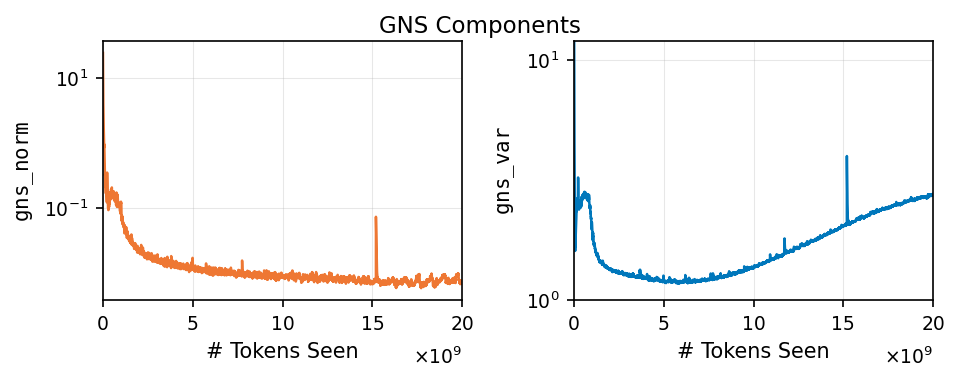

Saved nlp_gns_norm_var.pdf


In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, LogLocator, NullLocator

%matplotlib inline

# ADAPT THIS TO THE FILEPATH OF YOUR PARQUET FILE #
df = pd.read_parquet('nlp.parquet')

TOKENS_PER_SAMPLE = 1024

# fixed config: mid-range LR
WIDTH, BS, LR = 512, 1024, 0.0078125

mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 10, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 8, 'lines.linewidth': 1.2,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

run = df[
    (df['width'] == WIDTH) & (df['batch_size'] == BS) &
    (df['peak_lr'] == LR) & (df['seed'] == 111)
].sort_values('samples_seen').copy()

tokens_seen = run['samples_seen'].values * TOKENS_PER_SAMPLE

COL_WIDTH = 3.25
fig, axes = plt.subplots(1, 2, figsize=(COL_WIDTH * 2, COL_WIDTH * 0.8))

ylabels = [
    r'$\mathtt{gns\_norm}$',
    r'$\mathtt{gns\_var}$',
]
colors = ['#EE7733', '#0077BB']

for ax, values, ylabel, color in zip(axes,
                               [run['gns_norm'].values, run['gns_var'].values],
                               ylabels, colors):
    ax.plot(tokens_seen, values, color=color)
    ax.set_xlabel('# Tokens Seen')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 2e10)
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_major_locator(FixedLocator([0, 5e9, 10e9, 15e9, 20e9]))
    ax.xaxis.set_major_formatter(FixedFormatter(['0', '5', '10', '15', '20']))
    ax.text(1.0, -0.18, r'$\times 10^9$', transform=ax.transAxes,
            fontsize=9, ha='right', va='top')

axes[1].set_ylim(1e0, 12)

fig.suptitle('GNS Components', fontweight='medium', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig('nlp_gns_norm_var.pdf', dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()
print('Saved nlp_gns_norm_var.pdf')